In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV , train_test_split , cross_val_score, StratifiedKFold
import os
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    
)
from sklearn.preprocessing import label_binarize
import joblib
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')


In [5]:
os.listdir('archive')

['az_cybersecurity_real_logic.csv',
 'az_ecommerce_100k_clean.csv',
 'ev_qiymetleri.csv',
 'heart_disease_15k.csv']

In [6]:
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('archive/az_cybersecurity_real_logic.csv')

In [8]:
df.head()

,Paket_Ölçüsü,Paket_Sayı,Bağlantı_Müddəti,Port_Nömrəsi,Xəta_Sayı,Giriş_Cəhdi,CPU_İstifadəsi,RAM_İstifadəsi,Şəbəkə_Sürəti,Aktiv_Sessiya,Protokol,Cihaz_Növü,Şəbəkə_Növü,Şəhər,Hücum_Növü
0,NaN,18,8.510,443,30,289,39.2,26.2,16.91,5,HTTP,MacOS,Mobile,Gəncə,2
1,59586.0,4600,6821.740,445,8,8,96.4,91.8,508.25,18,TCP,Windows,Ethernet,Bakı,4
2,359.0,45808,1.938,35502,132,364,91.2,94.7,784.77,789,UDP,Linux,Mobile,Lənkəran,1
3,520.0,302,16.590,3389,1,3,19.6,32.6,12.42,17,HTTP,Linux,WiFi,Bakı,0
4,1757.0,400,21.990,21,0,2,46.3,37.3,29.02,5,HTTPS,Windows,Ethernet,Bakı,0


In [9]:
df.isna().sum()

Paket_Ölçüsü        2555
Paket_Sayı             0
Bağlantı_Müddəti       0
Port_Nömrəsi           0
Xəta_Sayı              0
Giriş_Cəhdi            0
CPU_İstifadəsi      2525
RAM_İstifadəsi      2601
Şəbəkə_Sürəti          0
Aktiv_Sessiya          0
Protokol               0
Cihaz_Növü             0
Şəbəkə_Növü            0
Şəhər                  0
Hücum_Növü             0
dtype: int64

In [10]:
df.dropna(axis=0,inplace=True , ignore_index=True)
df.isnull().sum()

Paket_Ölçüsü        0
Paket_Sayı          0
Bağlantı_Müddəti    0
Port_Nömrəsi        0
Xəta_Sayı           0
Giriş_Cəhdi         0
CPU_İstifadəsi      0
RAM_İstifadəsi      0
Şəbəkə_Sürəti       0
Aktiv_Sessiya       0
Protokol            0
Cihaz_Növü          0
Şəbəkə_Növü         0
Şəhər               0
Hücum_Növü          0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(1373)

In [12]:
df.drop_duplicates(inplace=True , ignore_index=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.shape

(92638, 15)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92638 entries, 0 to 92637
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Paket_Ölçüsü      92638 non-null  float64
 1   Paket_Sayı        92638 non-null  int64  
 2   Bağlantı_Müddəti  92638 non-null  float64
 3   Port_Nömrəsi      92638 non-null  int64  
 4   Xəta_Sayı         92638 non-null  int64  
 5   Giriş_Cəhdi       92638 non-null  int64  
 6   CPU_İstifadəsi    92638 non-null  float64
 7   RAM_İstifadəsi    92638 non-null  float64
 8   Şəbəkə_Sürəti     92638 non-null  float64
 9   Aktiv_Sessiya     92638 non-null  int64  
 10  Protokol          92638 non-null  object 
 11  Cihaz_Növü        92638 non-null  object 
 12  Şəbəkə_Növü       92638 non-null  object 
 13  Şəhər             92638 non-null  object 
 14  Hücum_Növü        92638 non-null  int64  
dtypes: float64(5), int64(6), object(4)
memory usage: 10.6+ MB


In [16]:
df

,Paket_Ölçüsü,Paket_Sayı,Bağlantı_Müddəti,Port_Nömrəsi,Xəta_Sayı,Giriş_Cəhdi,CPU_İstifadəsi,RAM_İstifadəsi,Şəbəkə_Sürəti,Aktiv_Sessiya,Protokol,Cihaz_Növü,Şəbəkə_Növü,Şəhər,Hücum_Növü
0,59586.0,4600,6821.740,445,8,8,96.4,91.8,508.25,18,TCP,Windows,Ethernet,Bakı,4
1,359.0,45808,1.938,35502,132,364,91.2,94.7,784.77,789,UDP,Linux,Mobile,Lənkəran,1
2,520.0,302,16.590,3389,1,3,19.6,32.6,12.42,17,HTTP,Linux,WiFi,Bakı,0
3,1757.0,400,21.990,21,0,2,46.3,37.3,29.02,5,HTTPS,Windows,Ethernet,Bakı,0
4,6288.0,476,3.870,3389,1,1,16.7,28.0,85.45,7,HTTPS,Windows,Ethernet,Sumqayıt,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92633,2847.0,83,12.320,8080,2,4,52.9,23.8,80.26,13,HTTP,Android,Ethernet,Sumqayıt,0
92634,7935.0,448,22.710,80,1,3,45.3,24.8,21.08,4,HTTPS,iOS,Ethernet,Lənkəran,0
92635,166.0,26,3.722,443,149,80,29.9,27.3,1.75,2,HTTP,Linux,Ethernet,Bakı,5
92636,4944.0,176,2.580,443,3,2,13.8,34.2,35.27,6,HTTP,iOS,WiFi,Lənkəran,0


# float görünür çünki içində boş dəyər (NaN) var idi. pandas NaN olan sütunu avtomatik float64-ə çevirir

In [17]:
df['Paket_Ölçüsü'] = df['Paket_Ölçüsü'].astype('int')

# 0: 'Normal',1: 'DDoS',2: 'Phishing',3: 'Malware',4: 'Ransomware',5: 'SQL Injection'  bunlar hücümların növləridir analiz edəndə başa düşürük

In [18]:
df.describe()

,Paket_Ölçüsü,Paket_Sayı,Bağlantı_Müddəti,Port_Nömrəsi,Xəta_Sayı,Giriş_Cəhdi,CPU_İstifadəsi,RAM_İstifadəsi,Şəbəkə_Sürəti,Aktiv_Sessiya,Hücum_Növü
count,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000,92638.000000
mean,5240.891243,2667.043481,289.521954,6828.445865,22.646139,56.280824,42.310370,45.984008,122.195268,109.387066,0.758490
std,9482.537773,8564.274386,975.731463,13511.384882,42.572030,125.006700,25.836966,23.764086,225.093901,356.885799,1.356154
min,64.000000,1.000000,0.001000,21.000000,0.000000,1.000000,5.000000,10.000000,0.100000,1.000000,0.000000
25%,1023.000000,104.000000,5.330000,80.000000,1.000000,2.000000,22.000000,26.700000,18.710000,5.000000,0.000000
50%,3311.500000,269.000000,13.850000,443.000000,3.000000,3.000000,37.500000,42.100000,47.010000,10.000000,0.000000
75%,5884.000000,435.000000,24.140000,8080.000000,21.000000,7.000000,55.500000,60.300000,81.550000,16.000000,1.000000
max,65532.000000,49994.000000,7196.580000,65516.000000,199.000000,499.000000,100.000000,99.000000,999.960000,1999.000000,5.000000


In [19]:
df['Hücum_Növü'].value_counts().sort_values(ascending=False)

Hücum_Növü
0    64889
1     7408
2     7407
3     6463
4     3701
5     2770
Name: count, dtype: int64

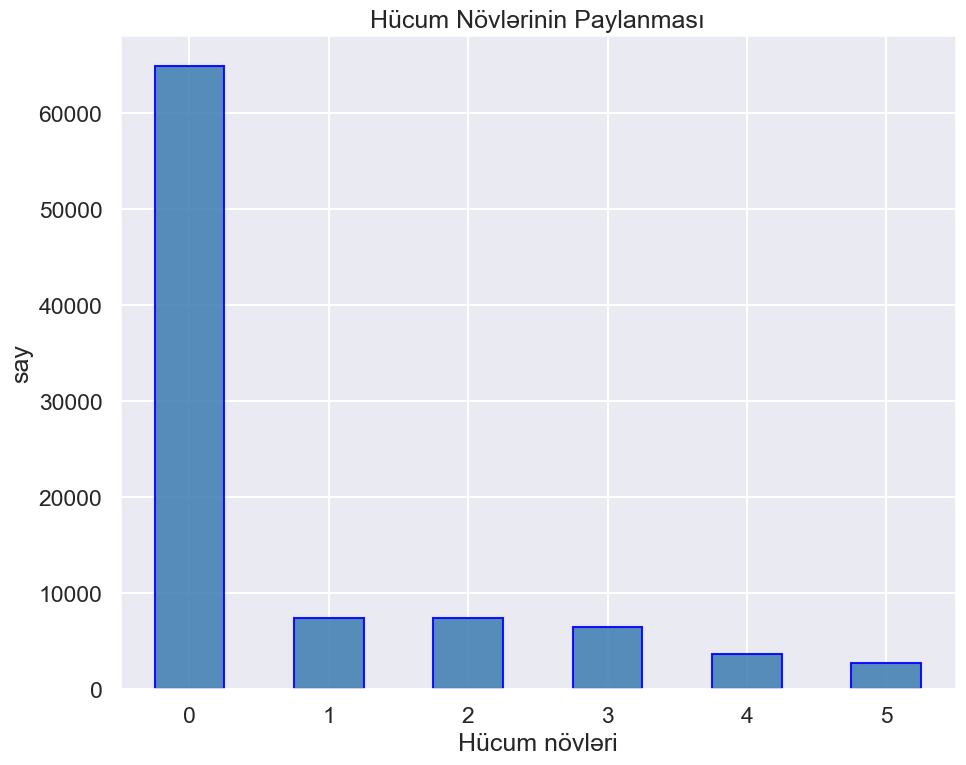

In [20]:
plt.figure(figsize=(10,8))
sns.set_style('darkgrid')
sns.set_context('talk')
df['Hücum_Növü'].value_counts().sort_index().plot(kind='bar' , alpha = 0.9  ,color='steelblue',edgecolor='blue')
plt.xticks(rotation=0, ha='center')
plt.xlabel('Hücum növləri')
plt.ylabel("say")
plt.title('Hücum Növlərinin Paylanması')
plt.tight_layout()
plt.grid(visible=True)
plt.show()


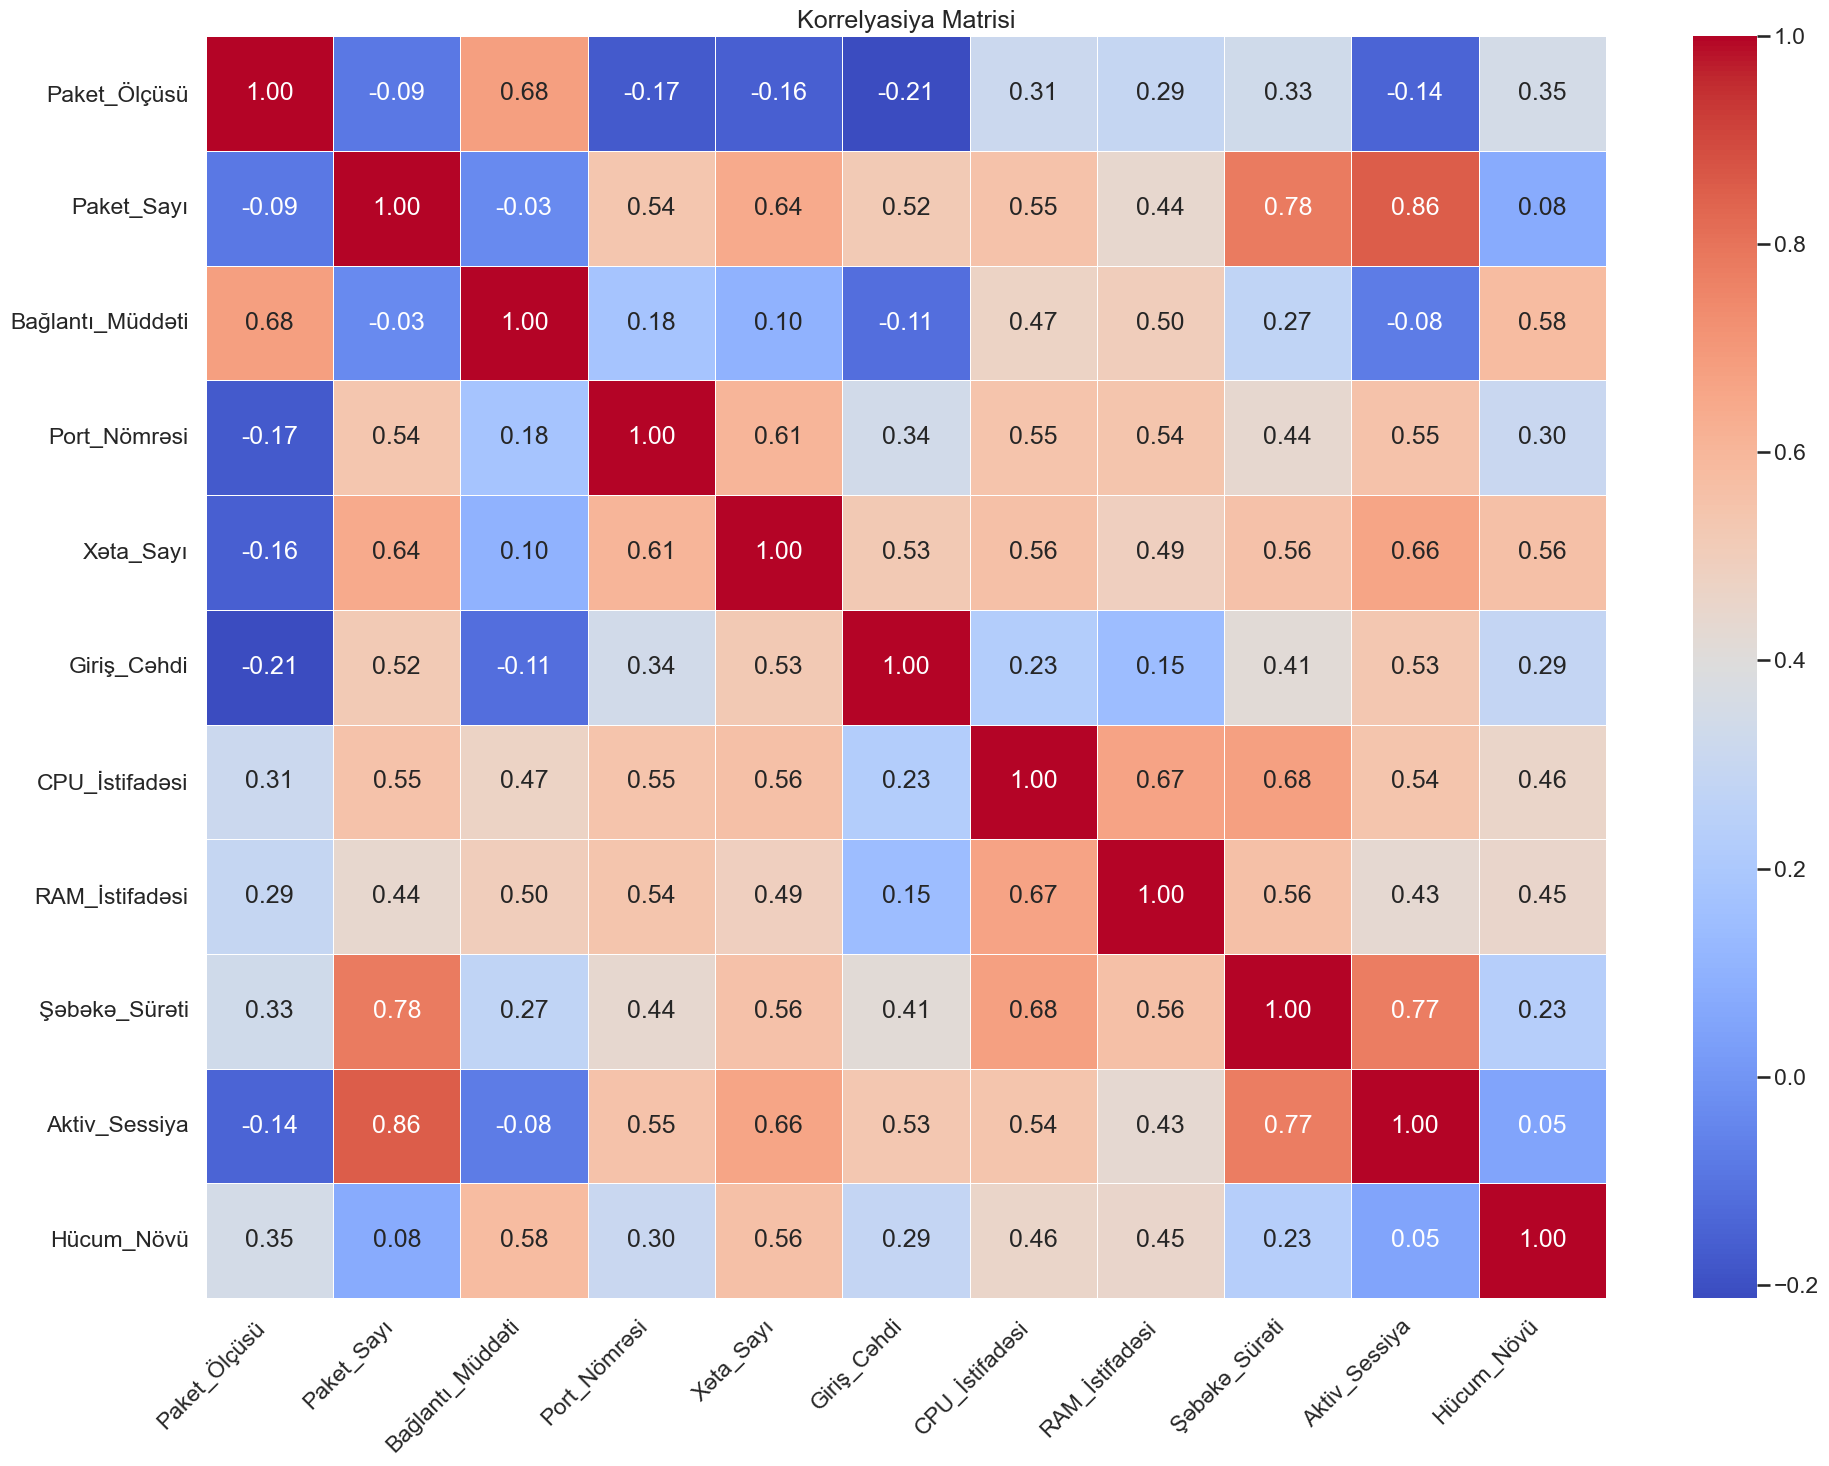

In [21]:
plt.figure(figsize=(20, 15) , dpi=100)
sns.set_style('whitegrid')
sns.set_context('talk')
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Korrelyasiya Matrisi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

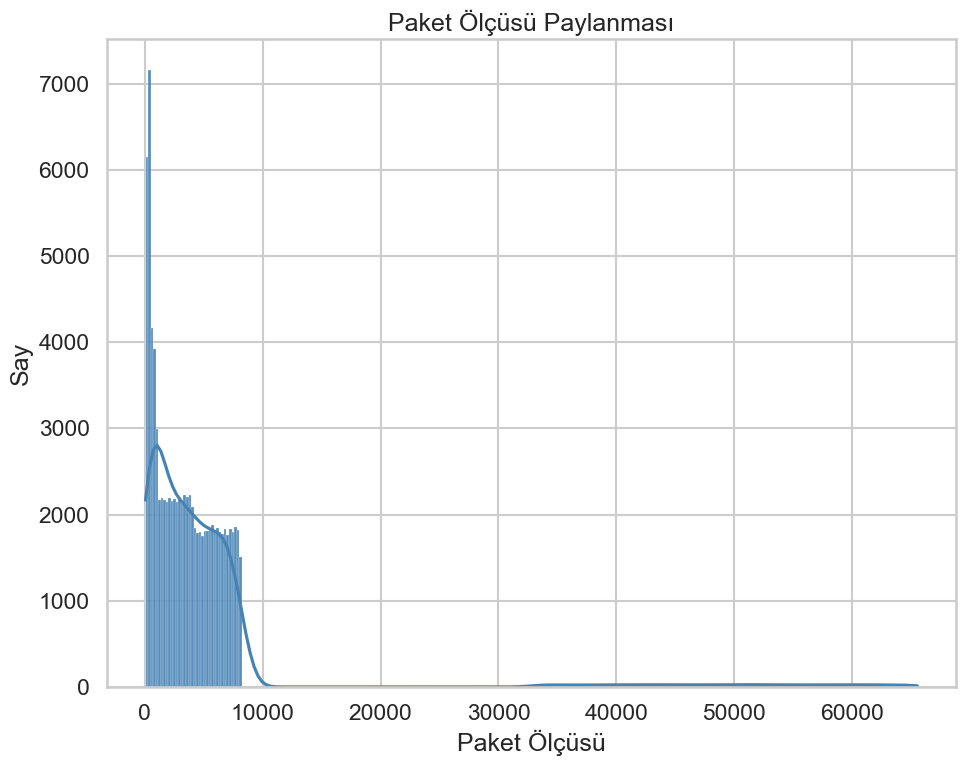

In [22]:
plt.figure(figsize=(10, 8))
sns.histplot(df['Paket_Ölçüsü'], kde=True , color='steelblue', alpha=0.9)
plt.title('Paket Ölçüsü Paylanması')
plt.xlabel('Paket Ölçüsü')
plt.ylabel('Say')
plt.grid(visible=True)
plt.tight_layout()
plt.show()

# nəticə ondan ibarətdirki isdifadəçilər 20-60 arası ən çox isdifadə edirlər amma 80-100 olanlar hücumlar olan hissədir

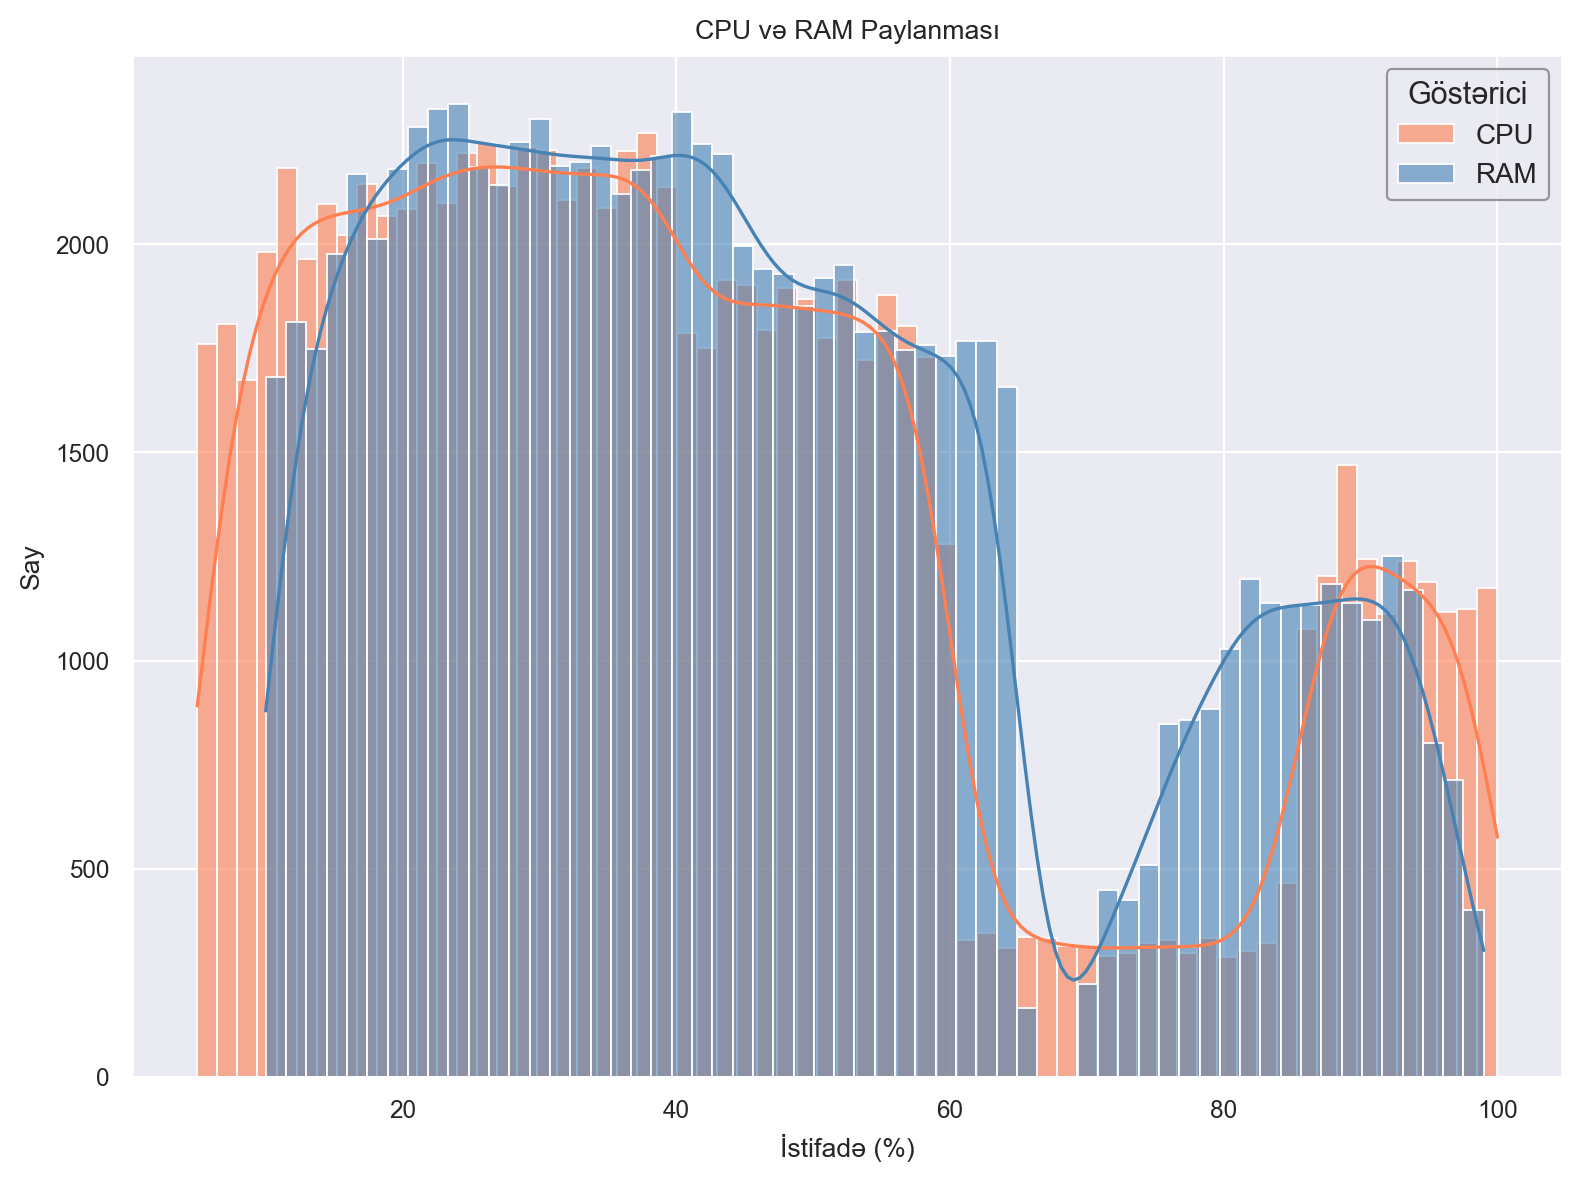

In [23]:
plt.figure(figsize=(8,6), dpi=200)
sns.set_style('darkgrid')
sns.set_context('paper')
sns.histplot(df['CPU_İstifadəsi'], kde=True, color='coral', alpha=0.6, label='CPU')
sns.histplot(df['RAM_İstifadəsi'], kde=True, color='steelblue', alpha=0.6, label='RAM')
plt.title('CPU və RAM Paylanması')
plt.xlabel('İstifadə (%)')
plt.ylabel('Say')
plt.legend(
    title='Göstərici',
    title_fontsize=11,
    fontsize=10,
    loc='upper right',
    framealpha=0.8,
    edgecolor='gray'
)
plt.grid(visible=True)
plt.tight_layout()
plt.show()

# outlier dəyərlər var bunları silmək lazım deyil çünki hücumun özüdür bu yüksək dəyərlər


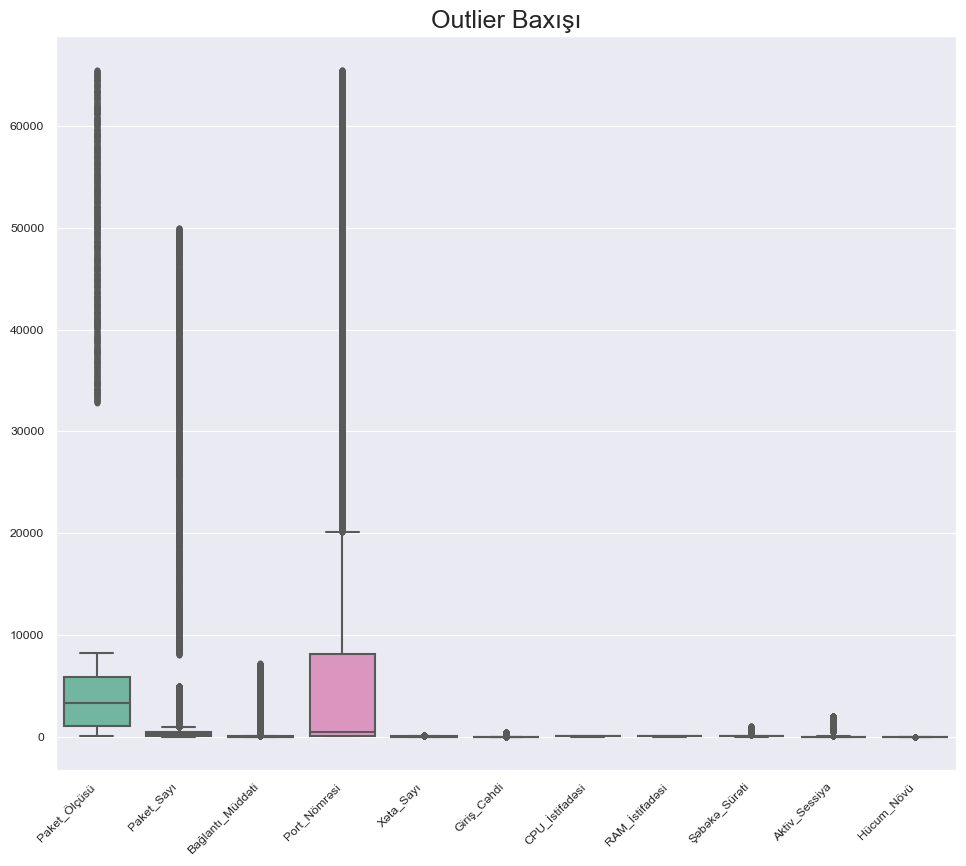

In [24]:
plt.figure(figsize=(10,9) , dpi=100)
plt.xticks(rotation=45 ,ha='right')
sns.set_style('darkgrid')
sns.set_context('talk')
sns.boxplot(
    data=df.select_dtypes(include='number'),
    palette='Set2',
    linewidth=1.5,         
    flierprops=dict(
        marker='o',         
        markersize=3,        
        alpha=0.4           
    )
)
plt.title('Outlier Baxışı')
plt.tight_layout()
plt.show()

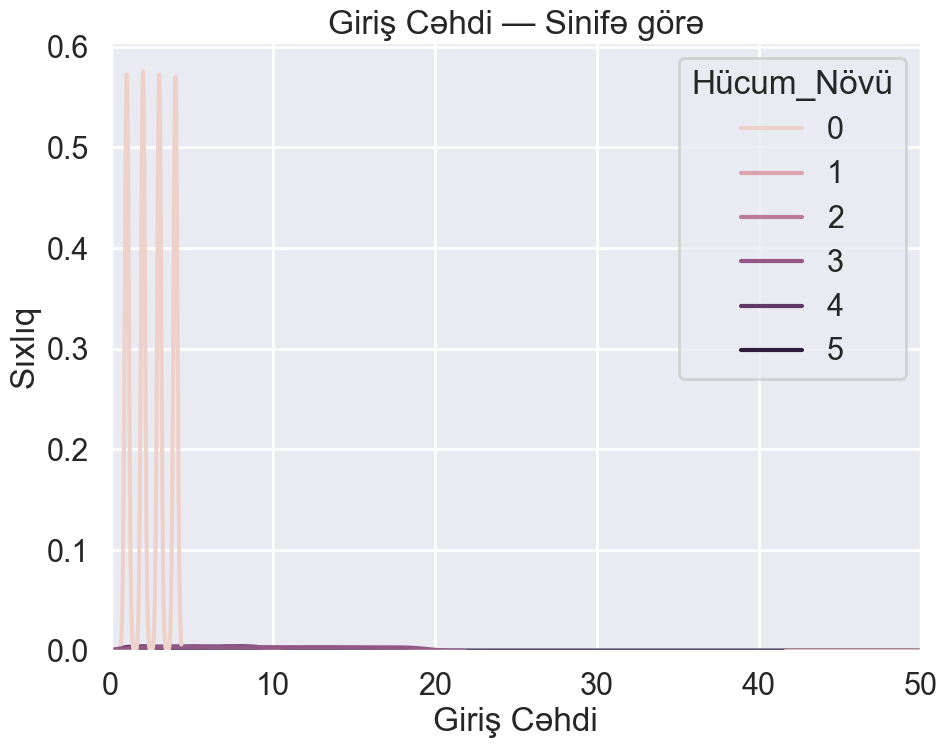

In [25]:
plt.figure(figsize=(10, 8))
sns.set_style('darkgrid')
sns.set_context('poster')
sns.kdeplot(data=df, x='Giriş_Cəhdi', hue='Hücum_Növü')
plt.xlim(0, 50) 
plt.title('Giriş Cəhdi — Sinifə görə')
plt.xlabel('Giriş Cəhdi')
plt.ylabel('Sıxlıq')
plt.tight_layout()
plt.show()

In [26]:
df

,Paket_Ölçüsü,Paket_Sayı,Bağlantı_Müddəti,Port_Nömrəsi,Xəta_Sayı,Giriş_Cəhdi,CPU_İstifadəsi,RAM_İstifadəsi,Şəbəkə_Sürəti,Aktiv_Sessiya,Protokol,Cihaz_Növü,Şəbəkə_Növü,Şəhər,Hücum_Növü
0,59586,4600,6821.740,445,8,8,96.4,91.8,508.25,18,TCP,Windows,Ethernet,Bakı,4
1,359,45808,1.938,35502,132,364,91.2,94.7,784.77,789,UDP,Linux,Mobile,Lənkəran,1
2,520,302,16.590,3389,1,3,19.6,32.6,12.42,17,HTTP,Linux,WiFi,Bakı,0
3,1757,400,21.990,21,0,2,46.3,37.3,29.02,5,HTTPS,Windows,Ethernet,Bakı,0
4,6288,476,3.870,3389,1,1,16.7,28.0,85.45,7,HTTPS,Windows,Ethernet,Sumqayıt,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92633,2847,83,12.320,8080,2,4,52.9,23.8,80.26,13,HTTP,Android,Ethernet,Sumqayıt,0
92634,7935,448,22.710,80,1,3,45.3,24.8,21.08,4,HTTPS,iOS,Ethernet,Lənkəran,0
92635,166,26,3.722,443,149,80,29.9,27.3,1.75,2,HTTP,Linux,Ethernet,Bakı,5
92636,4944,176,2.580,443,3,2,13.8,34.2,35.27,6,HTTP,iOS,WiFi,Lənkəran,0


# Bunlar categorikal olduğu üçün label encode ilə ettim

In [27]:
categorical_cols = ['Protokol' , 'Cihaz_Növü' ,'Şəbəkə_Növü' , 'Şəhər']
le_encode = LabelEncoder()
for col in categorical_cols:
    df[col] = le_encode.fit_transform(df[col])
df

,Paket_Ölçüsü,Paket_Sayı,Bağlantı_Müddəti,Port_Nömrəsi,Xəta_Sayı,Giriş_Cəhdi,CPU_İstifadəsi,RAM_İstifadəsi,Şəbəkə_Sürəti,Aktiv_Sessiya,Protokol,Cihaz_Növü,Şəbəkə_Növü,Şəhər,Hücum_Növü
0,59586,4600,6821.740,445,8,8,96.4,91.8,508.25,18,2,3,0,0,4
1,359,45808,1.938,35502,132,364,91.2,94.7,784.77,789,3,1,1,2,1
2,520,302,16.590,3389,1,3,19.6,32.6,12.42,17,0,1,3,0,0
3,1757,400,21.990,21,0,2,46.3,37.3,29.02,5,1,3,0,0,0
4,6288,476,3.870,3389,1,1,16.7,28.0,85.45,7,1,3,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92633,2847,83,12.320,8080,2,4,52.9,23.8,80.26,13,0,0,0,4,0
92634,7935,448,22.710,80,1,3,45.3,24.8,21.08,4,1,4,0,2,0
92635,166,26,3.722,443,149,80,29.9,27.3,1.75,2,0,1,0,0,5
92636,4944,176,2.580,443,3,2,13.8,34.2,35.27,6,0,4,3,2,0


In [28]:
X = df.drop(columns=['Hücum_Növü'])
y = df['Hücum_Növü']

In [29]:
X_train , X_test , y_train , y_test = train_test_split(X ,y , train_size=0.8 , random_state=42 , stratify=y)

In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# all = Hamısını ən böyüyə bərabərləşdirir , minority = Yalnız ən az olan sinifi artırır . bunlar sampling_strategy yerine yazıla biləcək şeylərdir. auto ilə not majority eyni şeydir.

In [31]:
smote= SMOTE(sampling_strategy='not majority' , random_state=42)
X_train_balanced , y_train_balanced = smote.fit_resample(X_train , y_train)
print(pd.Series(y_train).value_counts())

Hücum_Növü
0    51911
2     5926
1     5926
3     5170
4     2961
5     2216
Name: count, dtype: int64


# overfitting yoxladıq

In [32]:
logistic = LogisticRegression(max_iter=1000 , random_state=42)
logistic.fit(X_train_balanced , y_train_balanced)
train_accuracy = accuracy_score(y_true=y_train_balanced,y_pred=logistic.predict(X_train_balanced))
test_accuracy = accuracy_score(y_true=y_test , y_pred=logistic.predict(X_test))
print(f'Train: {train_accuracy:.4f}')
print(f'Test : {test_accuracy:.4f}')
print(f'Fərq : {train_accuracy - test_accuracy:.4f}')

Train: 1.0000
Test : 1.0000
Fərq : 0.0000


# f1_macro Hər sinifi bərabər çəki ilə qiymətləndirir — az olan sinif də önəmlidir. accuracy = sadəcə ümumi düzgünlük aldadıcı ola bilər

In [33]:
model = LogisticRegression(max_iter=1000)
params = [
    {
        'penalty': ['l2'],
        'solver': ['sag' , 'saga' , 'lbfgs' , 'newton-cg'],
        'C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'penalty': ['l1'],
        'solver':['liblinear' ,'saga'],
        'C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'penalty' : ['elasticnet'],
        'solver'  : ['saga'],
        'C'       : [0.01, 0.1, 1, 10, 100],
        'l1_ratio': [0.3, 0.5, 0.7]
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

GR = GridSearchCV(estimator=model ,param_grid=params , cv=cv ,verbose=1 , n_jobs=-1 , scoring='f1_macro')
GR.fit(X_train_balanced , y_train_balanced)

print('ən yaxşı parametrlər:' , GR.best_params_)
print('ən yaxşı F1 score :' , GR.best_score_)
best_model = GR.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 45 candidates, totalling 225 fits
ən yaxşı parametrlər: {'C': 0.01, 'penalty': 'l2', 'solver': 'sag'}
ən yaxşı F1 score : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12978
           1       1.00      1.00      1.00      1482
           2       1.00      1.00      1.00      1481
           3       1.00      1.00      1.00      1293
           4       1.00      1.00      1.00       740
           5       1.00      1.00      1.00       554

    accuracy                           1.00     18528
   macro avg       1.00      1.00      1.00     18528
weighted avg       1.00      1.00      1.00     18528



In [34]:
print('ən yaxşı parametrlər:' , GR.best_params_)
print('ən yaxşı F1 score :' , GR.best_score_)

best_model = GR.best_estimator_

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

ən yaxşı parametrlər: {'C': 0.01, 'penalty': 'l2', 'solver': 'sag'}
ən yaxşı F1 score : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12978
           1       1.00      1.00      1.00      1482
           2       1.00      1.00      1.00      1481
           3       1.00      1.00      1.00      1293
           4       1.00      1.00      1.00       740
           5       1.00      1.00      1.00       554

    accuracy                           1.00     18528
   macro avg       1.00      1.00      1.00     18528
weighted avg       1.00      1.00      1.00     18528



In [35]:
scores = cross_val_score(best_model, X_test, y_test, cv=5, scoring='f1_macro')
print('CV scores:', scores)
print('Ortalama :', scores.mean())

CV scores: [0.99095886 0.98833385 0.99235535 0.98696902 0.98563472]
Ortalama : 0.9888503603105374


# overfittindən şüpələndim amma overfitting deyil data çox aydın ayrılıbdır amma bu Smote ilə balanslaşdırılıbdır bizim nəticəmiz üstdəki nəticədir

In [36]:
scores = cross_val_score(best_model, X_train_balanced, y_train_balanced, cv=5, scoring='f1_macro')
print('CV scores:', scores)
print('Ortalama :', scores.mean())

CV scores: [1. 1. 1. 1. 1.]
Ortalama : 1.0


In [37]:
df.groupby('Hücum_Növü')[['Giriş_Cəhdi', 'CPU_İstifadəsi','RAM_İstifadəsi', 'Aktiv_Sessiya']].mean()

,Giriş_Cəhdi,CPU_İstifadəsi,RAM_İstifadəsi,Aktiv_Sessiya
Hücum_Növü,,,,
0,2.497773,32.464288,37.480260,9.976005
1,299.871895,92.391806,82.687959,1245.849082
2,350.279330,25.029810,29.827434,4.974484
3,9.937490,74.873712,86.433406,26.977719
4,5.039449,94.039935,89.407863,10.442043
5,55.168953,40.140072,37.836859,2.515162


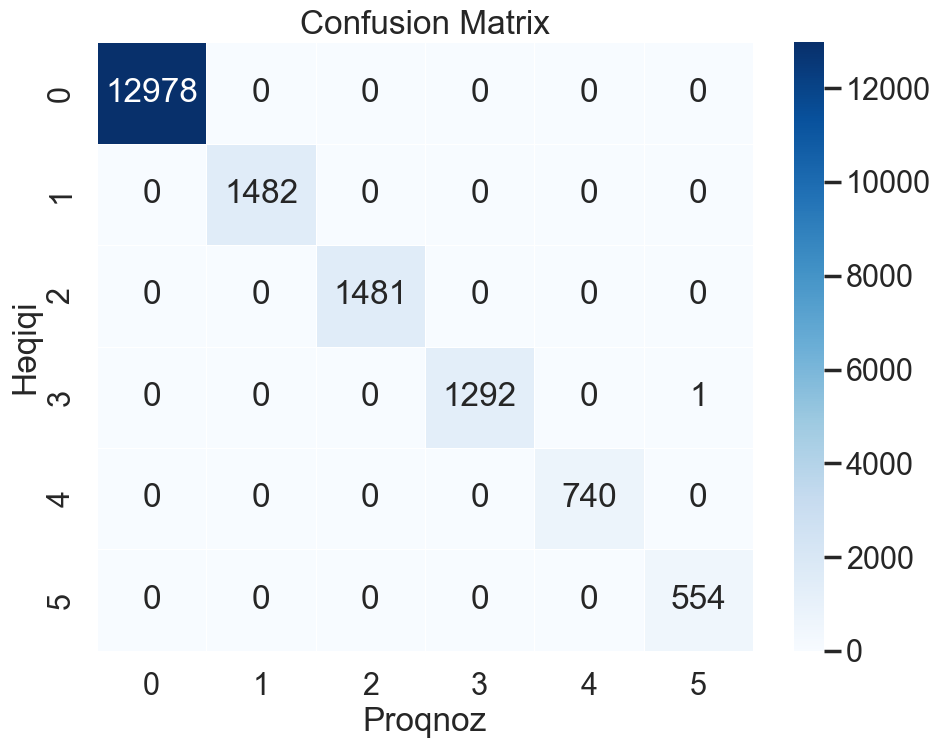

In [38]:
plt.figure(figsize=(10,8) , dpi=100)
sns.set_context('poster')
cm=confusion_matrix(y_true=y_test , y_pred=y_pred)
sns.heatmap(cm , annot=True, fmt='d', cmap='Blues',linewidths=0.5)
plt.title('Confusion Matrix')
plt.xlabel('Proqnoz')
plt.ylabel('Həqiqi')
plt.tight_layout()
plt.show()

In [39]:
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision : {precision_score(y_test, y_pred, average="macro"):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred, average="macro"):.4f}')
print(f'F1-macro  : {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'F1-weight : {f1_score(y_test, y_pred, average="weighted"):.4f}')

Accuracy  : 0.9999
Precision : 0.9997
Recall    : 0.9999
F1-macro  : 0.9998
F1-weight : 0.9999


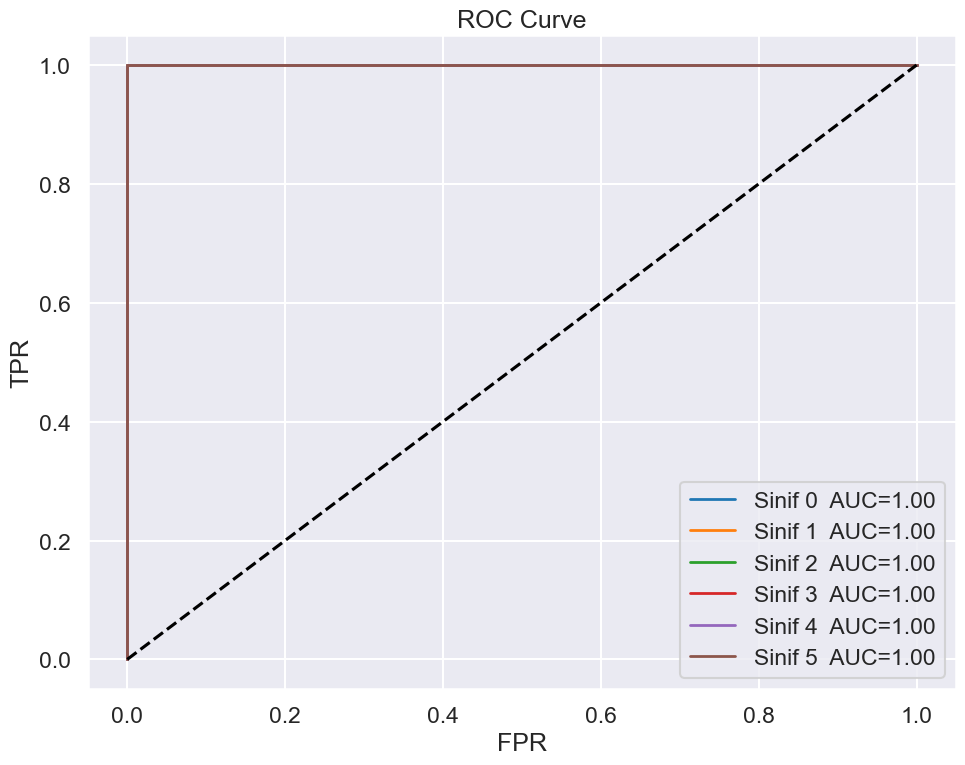

In [40]:
y_bin = label_binarize(y_test , classes=[0,1,2,3,4,5])
y_prob = best_model.predict_proba(X_test)
plt.figure(figsize=(10, 8))
sns.set_style('darkgrid')
sns.set_context('talk')
for i in range(6):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    auc = roc_auc_score(y_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'Sinif {i}  AUC={auc:.2f}')

plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.tight_layout()
plt.show()

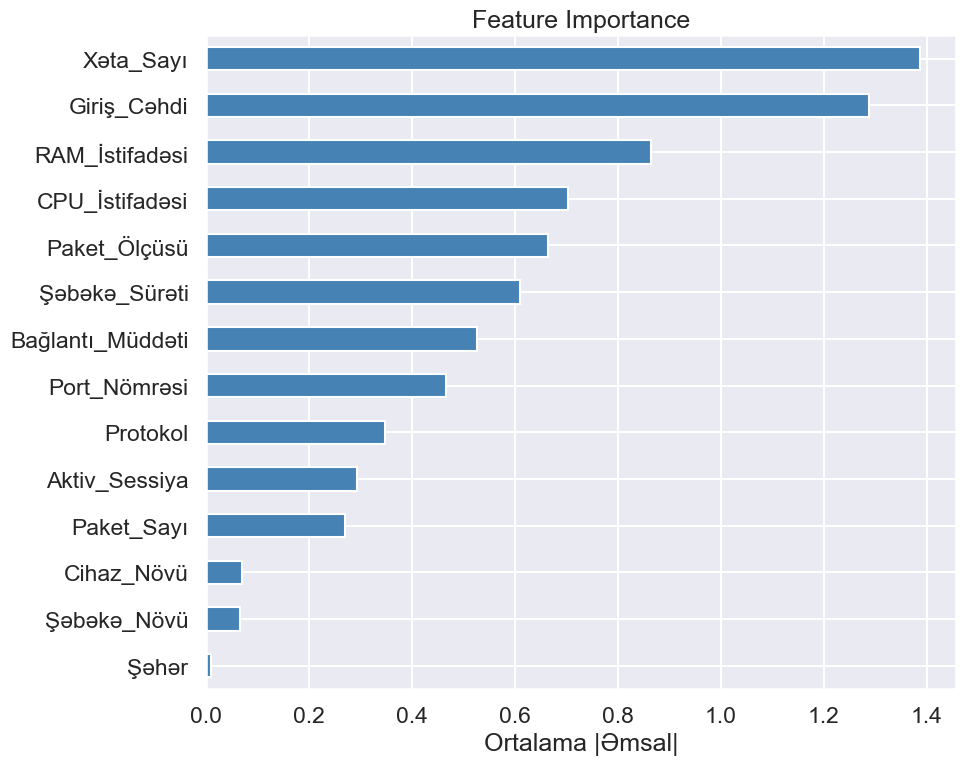

In [41]:
mean_coef = np.abs(best_model.coef_).mean(axis=0)
feat_imp = pd.Series(mean_coef , index=X.columns).sort_values()
plt.figure(figsize=(10, 8))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance')
plt.xlabel('Ortalama |Əmsal|')
plt.tight_layout()
plt.show()

In [42]:
sinif_adlari = {
    0: 'Normal',
    1: 'DDoS',
    2: 'Brute Force',
    3: 'Malware',
    4: 'Ransomware',
    5: 'SQL Injection'
}

# İstifadəçi məlumatları daxil edir
yeni_data = pd.DataFrame([{
    'Paket_Ölçüsü'    : 359,
    'Paket_Sayı'      : 45808,
    'Bağlantı_Müddəti': 1.938,
    'Port_Nömrəsi'    : 35502,
    'Xəta_Sayı'       : 132,
    'Giriş_Cəhdi'     : 364,
    'CPU_İstifadəsi'  : 91.2,
    'RAM_İstifadəsi'  : 94.7,
    'Şəbəkə_Sürəti'   : 784.77,
    'Aktiv_Sessiya'   : 789,
    'Protokol'        : 2,     
    'Cihaz_Növü'      : 3,
    'Şəbəkə_Növü'     : 2,
    'Şəhər'           : 4
}])

yeni_scaled = scaler.transform(yeni_data)
proqnoz     = best_model.predict(yeni_scaled)[0]

print(f'Proqnoz: {sinif_adlari[proqnoz]}')

Proqnoz: DDoS


In [43]:
os.makedirs('model' , exist_ok=True)
joblib.dump(best_model,'model/model.pkl')
joblib.dump(scaler,'model/scaler.pkl')

['model/scaler.pkl']